In [1]:
# IMPORTING LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
#IMPORTING DATASET
df=pd.read_csv("air_pollution_data.csv")
df

,city,date,aqi,co,no,no2,o3,so2,pm2_5,pm10,nh3
0,Ahmedabad,30-11-2020,Very Poor,520.71,2.38,16.28,130.18,47.68,65.96,72.13,8.36
1,Ahmedabad,01-12-2020,Very Poor,1682.28,7.71,54.84,0.73,21.70,120.95,154.53,27.36
2,Ahmedabad,02-12-2020,Very Poor,1815.80,16.54,49.35,0.17,23.84,133.47,172.63,28.12
3,Ahmedabad,03-12-2020,Very Poor,2296.45,41.57,40.10,0.00,35.76,150.37,202.15,36.48
4,Ahmedabad,04-12-2020,Very Poor,2189.64,23.92,58.95,0.02,28.13,160.79,205.80,40.53
...,...,...,...,...,...,...,...,...,...,...,...
23499,Visakhapatnam,21-05-2023,Moderate,353.81,0.00,2.08,100.14,4.11,37.53,47.09,0.08
23500,Visakhapatnam,22-05-2023,Moderate,380.52,0.00,3.77,82.97,5.07,32.17,43.44,1.74
23501,Visakhapatnam,23-05-2023,Moderate,390.53,0.00,4.28,80.11,5.19,36.01,48.06,1.20
23502,Visakhapatnam,24-05-2023,Moderate,300.41,0.00,1.36,95.84,2.21,30.17,48.89,0.00


In [3]:
df['date'] = pd.to_datetime(df['date'])

# Extract relevant date components
df['day'] = df['date'].dt.day
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year

# Drop or encode unnecessary information
df = df.drop('date', axis=1)

# Display the processed DataFrame
df

C:\Users\Akshay\AppData\Local\Temp\ipykernel_10120\838313132.py:1: UserWarning: Parsing '30-11-2020' in DD/MM/YYYY format. Provide format or specify infer_datetime_format=True for consistent parsing.
  df['date'] = pd.to_datetime(df['date'])
C:\Users\Akshay\AppData\Local\Temp\ipykernel_10120\838313132.py:1: UserWarning: Parsing '13-12-2020' in DD/MM/YYYY format. Provide format or specify infer_datetime_format=True for consistent parsing.
  df['date'] = pd.to_datetime(df['date'])
C:\Users\Akshay\AppData\Local\Temp\ipykernel_10120\838313132.py:1: UserWarning: Parsing '14-12-2020' in DD/MM/YYYY format. Provide format or specify infer_datetime_format=True for consistent parsing.
  df['date'] = pd.to_datetime(df['date'])
C:\Users\Akshay\AppData\Local\Temp\ipykernel_10120\838313132.py:1: UserWarning: Parsing '15-12-2020' in DD/MM/YYYY format. Provide format or specify infer_datetime_format=True for consistent parsing.
  df['date'] = pd.to_datetime(df['date'])
C:\Users\Akshay\AppData\Local\Te

,city,aqi,co,no,no2,o3,so2,pm2_5,pm10,nh3,day,month,year
0,Ahmedabad,Very Poor,520.71,2.38,16.28,130.18,47.68,65.96,72.13,8.36,30,11,2020
1,Ahmedabad,Very Poor,1682.28,7.71,54.84,0.73,21.70,120.95,154.53,27.36,12,1,2020
2,Ahmedabad,Very Poor,1815.80,16.54,49.35,0.17,23.84,133.47,172.63,28.12,12,2,2020
3,Ahmedabad,Very Poor,2296.45,41.57,40.10,0.00,35.76,150.37,202.15,36.48,12,3,2020
4,Ahmedabad,Very Poor,2189.64,23.92,58.95,0.02,28.13,160.79,205.80,40.53,12,4,2020
...,...,...,...,...,...,...,...,...,...,...,...,...,...
23499,Visakhapatnam,Moderate,353.81,0.00,2.08,100.14,4.11,37.53,47.09,0.08,21,5,2023
23500,Visakhapatnam,Moderate,380.52,0.00,3.77,82.97,5.07,32.17,43.44,1.74,22,5,2023
23501,Visakhapatnam,Moderate,390.53,0.00,4.28,80.11,5.19,36.01,48.06,1.20,23,5,2023
23502,Visakhapatnam,Moderate,300.41,0.00,1.36,95.84,2.21,30.17,48.89,0.00,24,5,2023


In [4]:
# EXPLORATORY DATA ANALYSIS

In [5]:
# to see the shape
df.shape

(23504, 13)

In [6]:
# to see statistical description
df.describe()

,co,no,no2,o3,so2,pm2_5,pm10,nh3,day,month,year
count,23504.000000,23504.00000,23504.000000,23504.000000,23504.000000,23504.000000,23504.000000,23504.000000,23504.000000,23504.000000,23504.000000
mean,1113.224543,6.00554,25.044104,35.059777,15.971449,98.598310,121.848091,12.060212,15.474558,6.301991,2021.684735
std,1401.770372,24.50272,25.839242,31.901760,23.943464,135.572391,160.429589,17.544759,8.960984,3.541323,0.777997
min,173.570000,0.00000,0.310000,0.000000,0.190000,0.500000,0.580000,0.000000,1.000000,1.000000,2020.000000
25%,447.270000,0.00000,8.740000,7.870000,4.470000,24.677500,32.277500,2.340000,7.000000,3.000000,2021.000000
50%,700.950000,0.00000,16.450000,28.250000,7.990000,58.860000,75.775000,6.520000,16.000000,6.000000,2022.000000
75%,1188.280000,0.27000,32.220000,54.360000,16.450000,117.605000,147.642500,15.830000,23.000000,9.000000,2022.000000
max,23071.290000,457.76000,331.760000,406.270000,442.510000,2203.550000,2429.130000,352.620000,31.000000,12.000000,2023.000000


In [7]:
# to see information about data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23504 entries, 0 to 23503
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   city    23504 non-null  object 
 1   aqi     23504 non-null  object 
 2   co      23504 non-null  float64
 3   no      23504 non-null  float64
 4   no2     23504 non-null  float64
 5   o3      23504 non-null  float64
 6   so2     23504 non-null  float64
 7   pm2_5   23504 non-null  float64
 8   pm10    23504 non-null  float64
 9   nh3     23504 non-null  float64
 10  day     23504 non-null  int64  
 11  month   23504 non-null  int64  
 12  year    23504 non-null  int64  
dtypes: float64(8), int64(3), object(2)
memory usage: 2.3+ MB


In [8]:
# to see columns/attributes
df.columns

Index(['city', 'aqi', 'co', 'no', 'no2', 'o3', 'so2', 'pm2_5', 'pm10', 'nh3',
       'day', 'month', 'year'],
      dtype='object')

In [9]:
# to see first 5 and last 5 rows
df.head()

,city,aqi,co,no,no2,o3,so2,pm2_5,pm10,nh3,day,month,year
0,Ahmedabad,Very Poor,520.71,2.38,16.28,130.18,47.68,65.96,72.13,8.36,30,11,2020
1,Ahmedabad,Very Poor,1682.28,7.71,54.84,0.73,21.70,120.95,154.53,27.36,12,1,2020
2,Ahmedabad,Very Poor,1815.80,16.54,49.35,0.17,23.84,133.47,172.63,28.12,12,2,2020
3,Ahmedabad,Very Poor,2296.45,41.57,40.10,0.00,35.76,150.37,202.15,36.48,12,3,2020
4,Ahmedabad,Very Poor,2189.64,23.92,58.95,0.02,28.13,160.79,205.80,40.53,12,4,2020


In [10]:
df.tail()

,city,aqi,co,no,no2,o3,so2,pm2_5,pm10,nh3,day,month,year
23499,Visakhapatnam,Moderate,353.81,0.0,2.08,100.14,4.11,37.53,47.09,0.08,21,5,2023
23500,Visakhapatnam,Moderate,380.52,0.0,3.77,82.97,5.07,32.17,43.44,1.74,22,5,2023
23501,Visakhapatnam,Moderate,390.53,0.0,4.28,80.11,5.19,36.01,48.06,1.20,23,5,2023
23502,Visakhapatnam,Moderate,300.41,0.0,1.36,95.84,2.21,30.17,48.89,0.00,24,5,2023
23503,Visakhapatnam,Poor,427.25,0.0,6.00,88.69,10.73,52.36,61.41,0.20,25,5,2023


In [11]:
# to see unique city in city columns
df['city'].unique()         

array(['Ahmedabad', 'Aizawl', 'Amaravati', 'Amritsar', 'Bengaluru',
       'Bhopal', 'Brajrajnagar', 'Chandigarh', 'Chennai', 'Coimbatore',
       'Delhi', 'Ernakulam', 'Gurugram', 'Guwahati', 'Hyderabad',
       'Jaipur', 'Jorapokhar', 'Kochi', 'Kolkata', 'Lucknow', 'Mumbai',
       'Patna', 'Shillong', 'Talcher', 'Thiruvananthapuram',
       'Visakhapatnam'], dtype=object)

In [12]:
# here we have 26 cities

In [13]:
# Here we have 5 categories of AQI

In [14]:
# to see unique standard AQI
df['aqi'].unique() 

array(['Very Poor', ' Poor', 'Fair', 'Good', 'Moderate'], dtype=object)

In [15]:
#To see count of values of standard AQI
df['aqi'].value_counts()              # maximum of standard 5 means severe cases

Very Poor    12458
 Poor         4324
Good          2618
Fair          2372
Moderate      1732
Name: aqi, dtype: int64

<AxesSubplot:xlabel='aqi', ylabel='Count'>

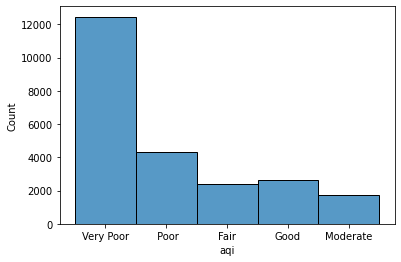

In [16]:
sns.histplot(df['aqi'])

In [17]:
# to see total no.of unique values
df.nunique()

city        26
aqi          5
co         492
no         670
no2        601
o3         636
so2        646
pm2_5    13663
pm10     14840
nh3        613
day         31
month       12
year         4
dtype: int64

In [18]:
# records where city  is Ahmedabad and aqi shows very Poor

In [19]:
df[(df['city']=="Ahmedabad") & (df['aqi']=="Very Poor")]

,city,aqi,co,no,no2,o3,so2,pm2_5,pm10,nh3,day,month,year
0,Ahmedabad,Very Poor,520.71,2.38,16.28,130.18,47.68,65.96,72.13,8.36,30,11,2020
1,Ahmedabad,Very Poor,1682.28,7.71,54.84,0.73,21.70,120.95,154.53,27.36,12,1,2020
2,Ahmedabad,Very Poor,1815.80,16.54,49.35,0.17,23.84,133.47,172.63,28.12,12,2,2020
3,Ahmedabad,Very Poor,2296.45,41.57,40.10,0.00,35.76,150.37,202.15,36.48,12,3,2020
4,Ahmedabad,Very Poor,2189.64,23.92,58.95,0.02,28.13,160.79,205.80,40.53,12,4,2020
...,...,...,...,...,...,...,...,...,...,...,...,...,...
867,Ahmedabad,Very Poor,2750.40,54.09,36.33,0.00,68.66,132.41,186.54,51.17,19,4,2023
872,Ahmedabad,Very Poor,1602.17,7.71,50.72,0.51,40.53,78.39,114.58,25.33,24,4,2023
874,Ahmedabad,Very Poor,4005.43,44.70,82.25,0.00,103.00,238.97,286.67,61.81,26,4,2023
882,Ahmedabad,Very Poor,1976.01,2.63,69.23,2.50,47.68,126.96,163.14,25.59,5,4,2023


In [20]:
# records where city is delhi and aqi is Poor
df[(df['city']=="Delhi") & (df['aqi']=="Very Poor")]

,city,aqi,co,no,no2,o3,so2,pm2_5,pm10,nh3,day,month,year
9040,Delhi,Very Poor,988.01,1.24,13.71,205.99,34.33,133.73,156.15,9.88,30,11,2020
9041,Delhi,Very Poor,3150.94,30.40,66.49,0.00,14.90,299.99,428.61,16.09,12,1,2020
9042,Delhi,Very Poor,3524.78,18.11,71.97,0.05,12.16,455.67,571.47,10.64,12,2,2020
9043,Delhi,Very Poor,1922.61,0.03,52.78,27.54,11.09,208.94,266.25,10.13,12,3,2020
9044,Delhi,Very Poor,3738.40,0.64,78.14,11.00,16.69,595.27,748.71,10.26,12,4,2020
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9933,Delhi,Very Poor,6355.29,67.06,95.96,0.00,103.95,395.87,579.79,57.76,15,5,2023
9934,Delhi,Very Poor,3204.35,10.84,67.17,0.36,62.94,202.46,347.05,30.15,16,5,2023
9939,Delhi,Very Poor,3070.83,12.85,81.57,0.08,69.62,172.37,327.52,66.88,21,5,2023
9940,Delhi,Very Poor,1575.47,0.32,50.04,9.92,31.95,81.03,186.17,23.31,22,5,2023


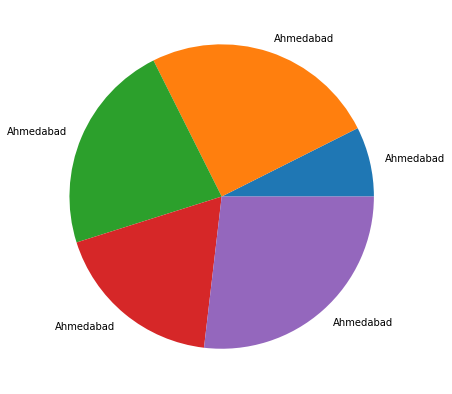

In [21]:
fig = plt.figure(figsize =(15, 7))
plt.pie(df['no2'].head(5), labels = df['city'].head(5))

# show plot
plt.show()

<AxesSubplot:xlabel='co', ylabel='city'>

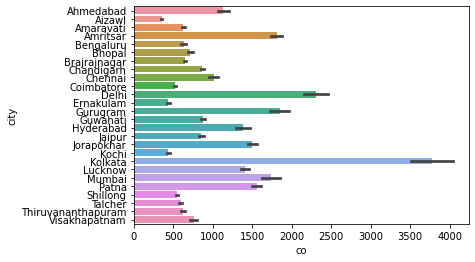

In [22]:
# to see bar distribution of 
sns.barplot(x='co', y='city', data=df)

<AxesSubplot:xlabel='no', ylabel='city'>

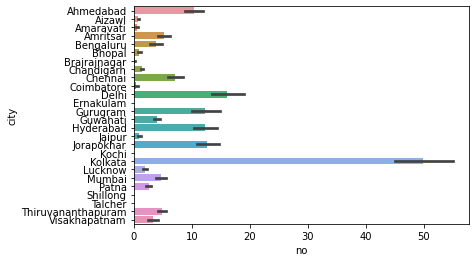

In [23]:
# to see bar distribution of 
sns.barplot(x='no', y='city', data=df)

<AxesSubplot:>

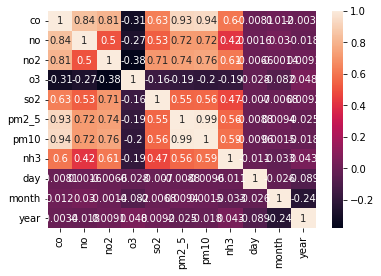

In [24]:
# to see correlation in heatmap
sns.heatmap(df.corr(),annot=True)

<AxesSubplot:xlabel='co', ylabel='no'>

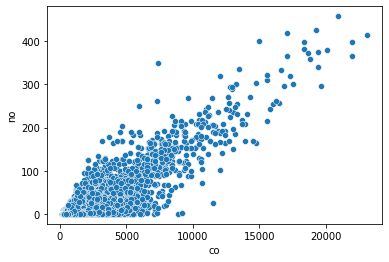

In [25]:
# to see scatter plot for relationship betwee co and no
sns.scatterplot(x="co",y='no',data=df)

<AxesSubplot:xlabel='no', ylabel='o3'>

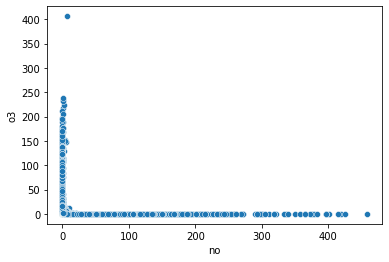

In [26]:
# to see scatter plot for relationship between no and o3
sns.scatterplot(x="no",y='o3',data=df)

<AxesSubplot:xlabel='pm2_5', ylabel='pm10'>

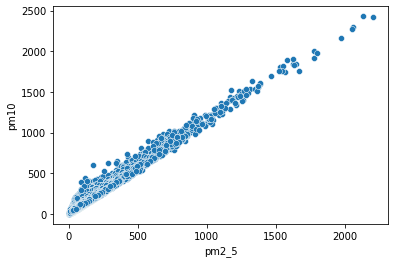

In [27]:
 #to see scatter plot for relationship between no and o3
sns.scatterplot(x="pm2_5",y='pm10',data=df)

In [28]:
# to see correlation
df.corr()

,co,no,no2,o3,so2,pm2_5,pm10,nh3,day,month,year
co,1.000000,0.843799,0.805820,-0.313232,0.631510,0.929881,0.935345,0.603286,-0.008076,0.012134,-0.003418
no,0.843799,1.000000,0.499226,-0.267879,0.532777,0.719160,0.718655,0.416600,0.001639,0.030423,-0.017672
no2,0.805820,0.499226,1.000000,-0.380578,0.708760,0.737977,0.755135,0.608555,-0.006565,-0.001430,0.009093
o3,-0.313232,-0.267879,-0.380578,1.000000,-0.163729,-0.191523,-0.203824,-0.192751,-0.027939,-0.081670,0.047691
so2,0.631510,0.532777,0.708760,-0.163729,1.000000,0.552935,0.562396,0.468437,-0.007025,-0.006754,0.009188
pm2_5,0.929881,0.719160,0.737977,-0.191523,0.552935,1.000000,0.990648,0.558785,-0.008814,0.009382,-0.024737
pm10,0.935345,0.718655,0.755135,-0.203824,0.562396,0.990648,1.000000,0.586979,-0.009567,0.001504,-0.018249
nh3,0.603286,0.416600,0.608555,-0.192751,0.468437,0.558785,0.586979,1.000000,-0.010987,-0.033074,0.042999
day,-0.008076,0.001639,-0.006565,-0.027939,-0.007025,-0.008814,-0.009567,-0.010987,1.000000,-0.026304,-0.088503
month,0.012134,0.030423,-0.001430,-0.081670,-0.006754,0.009382,0.001504,-0.033074,-0.026304,1.000000,-0.235665


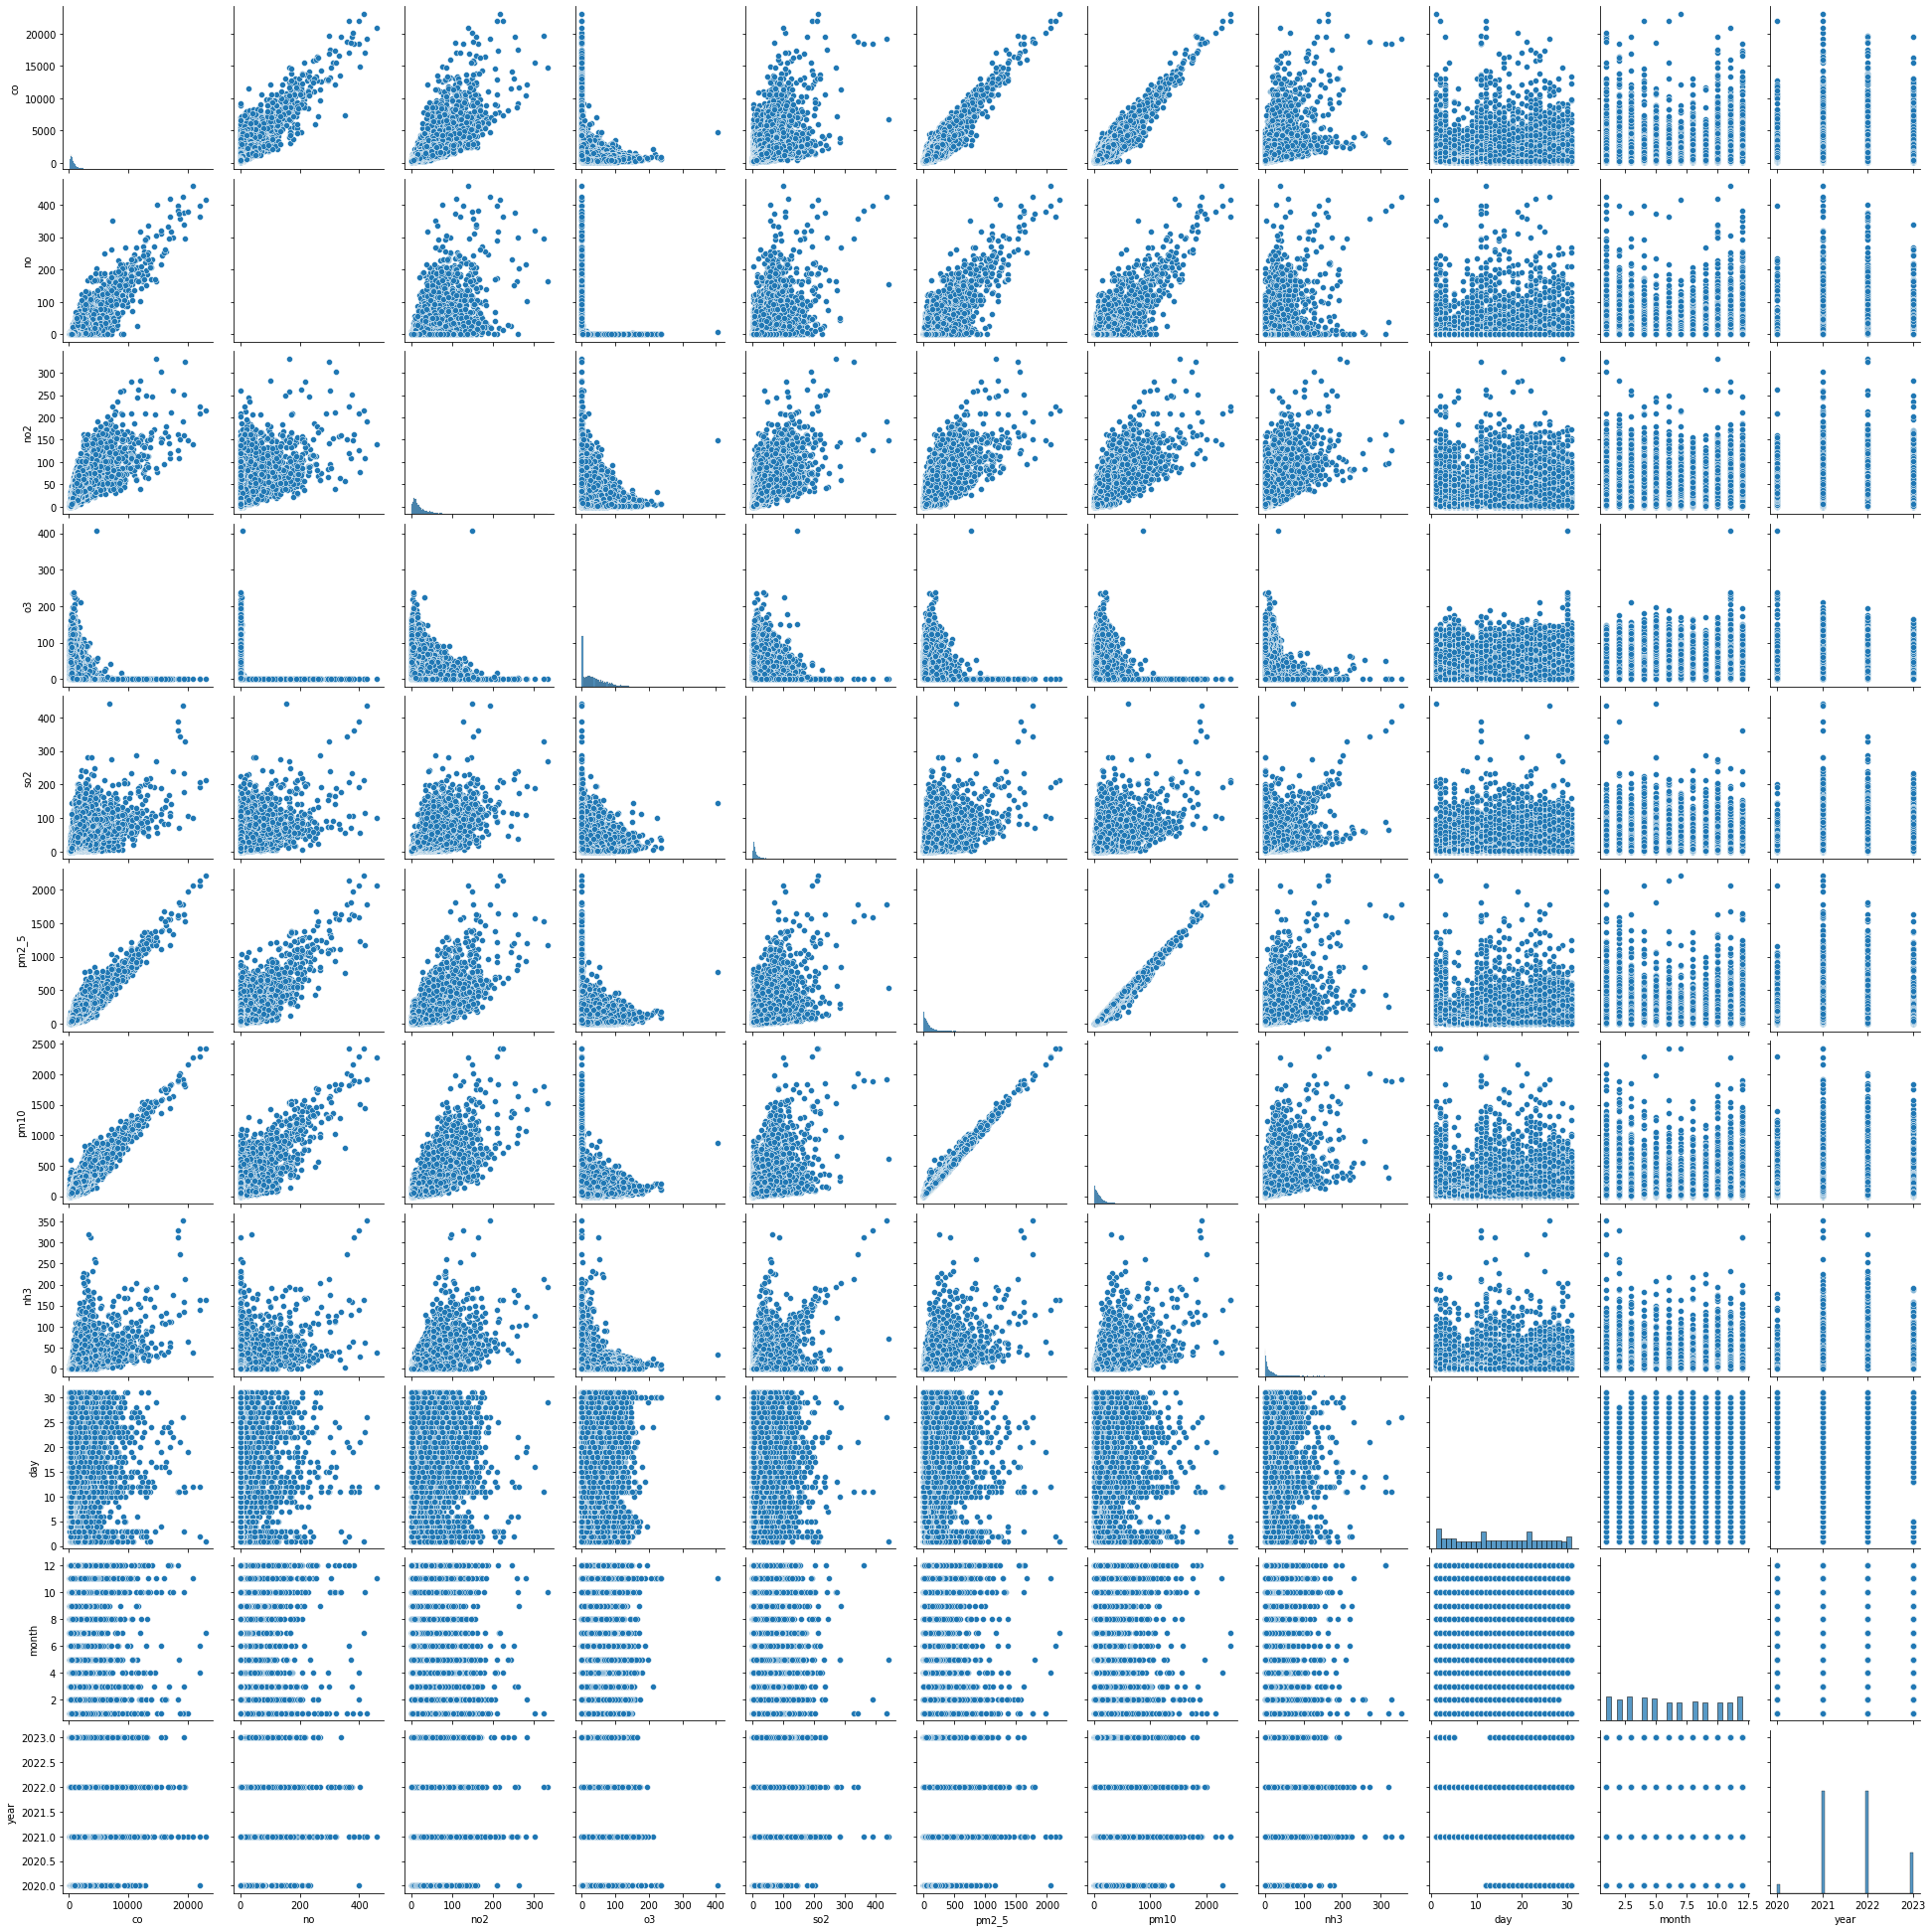

In [29]:
#let visulaize
sns.pairplot(df)
plt.show()

<AxesSubplot:ylabel='Count'>

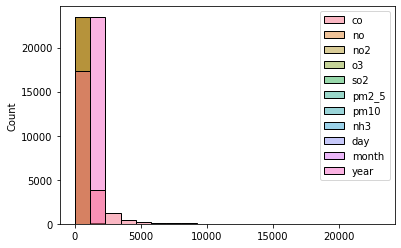

In [30]:
sns.histplot(bins=20,data=df)

In [31]:
# Now to apply encoding on few columns
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['city']=le.fit_transform(df['city'])
df['aqi']=le.fit_transform(df['aqi'])

In [32]:
print(df)

       city  aqi       co     no    no2      o3    so2   pm2_5    pm10    nh3  \
0         0    4   520.71   2.38  16.28  130.18  47.68   65.96   72.13   8.36   
1         0    4  1682.28   7.71  54.84    0.73  21.70  120.95  154.53  27.36   
2         0    4  1815.80  16.54  49.35    0.17  23.84  133.47  172.63  28.12   
3         0    4  2296.45  41.57  40.10    0.00  35.76  150.37  202.15  36.48   
4         0    4  2189.64  23.92  58.95    0.02  28.13  160.79  205.80  40.53   
...     ...  ...      ...    ...    ...     ...    ...     ...     ...    ...   
23499    25    3   353.81   0.00   2.08  100.14   4.11   37.53   47.09   0.08   
23500    25    3   380.52   0.00   3.77   82.97   5.07   32.17   43.44   1.74   
23501    25    3   390.53   0.00   4.28   80.11   5.19   36.01   48.06   1.20   
23502    25    3   300.41   0.00   1.36   95.84   2.21   30.17   48.89   0.00   
23503    25    0   427.25   0.00   6.00   88.69  10.73   52.36   61.41   0.20   

       day  month  year  
0

In [33]:
# HERE 4 denotes Very Poor, 3 denotes Poor, 2 denotes Moderate, 1 denotes Fair, 0 denotes Good

In [34]:
# Now To extract independent and dependent variables
X = df.iloc[:,[0, 2,4,5,6,7,8,9,12]].values
Y = df.iloc[:, 1].values

In [35]:
print(X)

[[0.00000e+00 5.20710e+02 1.62800e+01 ... 7.21300e+01 8.36000e+00
  2.02000e+03]
 [0.00000e+00 1.68228e+03 5.48400e+01 ... 1.54530e+02 2.73600e+01
  2.02000e+03]
 [0.00000e+00 1.81580e+03 4.93500e+01 ... 1.72630e+02 2.81200e+01
  2.02000e+03]
 ...
 [2.50000e+01 3.90530e+02 4.28000e+00 ... 4.80600e+01 1.20000e+00
  2.02300e+03]
 [2.50000e+01 3.00410e+02 1.36000e+00 ... 4.88900e+01 0.00000e+00
  2.02300e+03]
 [2.50000e+01 4.27250e+02 6.00000e+00 ... 6.14100e+01 2.00000e-01
  2.02300e+03]]


In [36]:
Y

array([4, 4, 4, ..., 3, 3, 0])

In [37]:
#Now Split the data in training and testing
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.25,random_state=5)

In [38]:
df

,city,aqi,co,no,no2,o3,so2,pm2_5,pm10,nh3,day,month,year
0,0,4,520.71,2.38,16.28,130.18,47.68,65.96,72.13,8.36,30,11,2020
1,0,4,1682.28,7.71,54.84,0.73,21.70,120.95,154.53,27.36,12,1,2020
2,0,4,1815.80,16.54,49.35,0.17,23.84,133.47,172.63,28.12,12,2,2020
3,0,4,2296.45,41.57,40.10,0.00,35.76,150.37,202.15,36.48,12,3,2020
4,0,4,2189.64,23.92,58.95,0.02,28.13,160.79,205.80,40.53,12,4,2020
...,...,...,...,...,...,...,...,...,...,...,...,...,...
23499,25,3,353.81,0.00,2.08,100.14,4.11,37.53,47.09,0.08,21,5,2023
23500,25,3,380.52,0.00,3.77,82.97,5.07,32.17,43.44,1.74,22,5,2023
23501,25,3,390.53,0.00,4.28,80.11,5.19,36.01,48.06,1.20,23,5,2023
23502,25,3,300.41,0.00,1.36,95.84,2.21,30.17,48.89,0.00,24,5,2023


In [39]:
X

array([[0.00000e+00, 5.20710e+02, 1.62800e+01, ..., 7.21300e+01,
        8.36000e+00, 2.02000e+03],
       [0.00000e+00, 1.68228e+03, 5.48400e+01, ..., 1.54530e+02,
        2.73600e+01, 2.02000e+03],
       [0.00000e+00, 1.81580e+03, 4.93500e+01, ..., 1.72630e+02,
        2.81200e+01, 2.02000e+03],
       ...,
       [2.50000e+01, 3.90530e+02, 4.28000e+00, ..., 4.80600e+01,
        1.20000e+00, 2.02300e+03],
       [2.50000e+01, 3.00410e+02, 1.36000e+00, ..., 4.88900e+01,
        0.00000e+00, 2.02300e+03],
       [2.50000e+01, 4.27250e+02, 6.00000e+00, ..., 6.14100e+01,
        2.00000e-01, 2.02300e+03]])

In [40]:
Y_test

array([4, 1, 4, ..., 1, 0, 2])

In [41]:
X_train

array([[2.40000e+01, 7.00950e+02, 1.54200e+01, ..., 4.07400e+01,
        2.31000e+00, 2.02300e+03],
       [1.70000e+01, 4.67300e+02, 8.31000e+00, ..., 7.64400e+01,
        9.40000e-01, 2.02300e+03],
       [3.00000e+00, 1.94931e+03, 6.58000e+01, ..., 1.66480e+02,
        9.22100e+01, 2.02200e+03],
       ...,
       [2.20000e+01, 2.93730e+02, 5.48000e+00, ..., 5.75000e+00,
        3.80000e-01, 2.02200e+03],
       [2.00000e+01, 2.63690e+02, 7.54000e+00, ..., 5.02000e+00,
        1.04000e+00, 2.02200e+03],
       [3.00000e+00, 6.40870e+02, 7.11000e+00, ..., 7.24100e+01,
        2.35600e+01, 2.02100e+03]])

# APPLY LOGISTIC REGRESSION

In [42]:
# Now to apply models
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr.fit(X_train,Y_train)

C:\Users\Akshay\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [43]:
lr_pred=lr.predict(X_test)
lr_pred

array([4, 2, 4, ..., 1, 0, 1])

In [44]:
# to check classification report
from sklearn.metrics import classification_report
print(classification_report(Y_test,lr_pred))

              precision    recall  f1-score   support

           0       0.66      0.75      0.70      1084
           1       0.63      0.64      0.63       544
           2       0.79      0.87      0.83       640
           3       0.42      0.20      0.28       454
           4       0.94      0.95      0.95      3154

    accuracy                           0.82      5876
   macro avg       0.69      0.68      0.68      5876
weighted avg       0.81      0.82      0.81      5876



In [45]:
X

array([[0.00000e+00, 5.20710e+02, 1.62800e+01, ..., 7.21300e+01,
        8.36000e+00, 2.02000e+03],
       [0.00000e+00, 1.68228e+03, 5.48400e+01, ..., 1.54530e+02,
        2.73600e+01, 2.02000e+03],
       [0.00000e+00, 1.81580e+03, 4.93500e+01, ..., 1.72630e+02,
        2.81200e+01, 2.02000e+03],
       ...,
       [2.50000e+01, 3.90530e+02, 4.28000e+00, ..., 4.80600e+01,
        1.20000e+00, 2.02300e+03],
       [2.50000e+01, 3.00410e+02, 1.36000e+00, ..., 4.88900e+01,
        0.00000e+00, 2.02300e+03],
       [2.50000e+01, 4.27250e+02, 6.00000e+00, ..., 6.14100e+01,
        2.00000e-01, 2.02300e+03]])

# Decision Tree 

In [46]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier()
dt.fit(X_train,Y_train)

DecisionTreeClassifier()

In [47]:
dt_pred=dt.predict(X_test)
dt_pred

array([4, 1, 4, ..., 1, 0, 2])

In [48]:
# to check classification report
from sklearn.metrics import classification_report
print(classification_report(Y_test,dt_pred))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1084
           1       0.99      1.00      0.99       544
           2       1.00      1.00      1.00       640
           3       0.96      0.97      0.96       454
           4       1.00      1.00      1.00      3154

    accuracy                           0.99      5876
   macro avg       0.99      0.99      0.99      5876
weighted avg       0.99      0.99      0.99      5876



# Random Forest

In [49]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(n_estimators=100)
rf.fit(X_train,Y_train)

RandomForestClassifier()

In [50]:
rf_pred=rf.predict(X_test)
rf_pred

array([4, 1, 4, ..., 1, 0, 2])

In [51]:
# to check classification report
from sklearn.metrics import classification_report
print(classification_report(Y_test,rf_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1084
           1       1.00      0.99      0.99       544
           2       1.00      1.00      1.00       640
           3       0.99      0.98      0.98       454
           4       1.00      1.00      1.00      3154

    accuracy                           1.00      5876
   macro avg       0.99      0.99      0.99      5876
weighted avg       1.00      1.00      1.00      5876



# SVM

In [52]:
from sklearn.svm import SVC
svm=SVC(kernel="rbf")
svm.fit(X_train,Y_train)

SVC()

In [53]:
svm_pred=svm.predict(X_test)
svm_pred

array([4, 2, 4, ..., 2, 0, 1])

In [54]:
# to check classification report
from sklearn.metrics import classification_report
print(classification_report(Y_test,svm_pred))

              precision    recall  f1-score   support

           0       0.56      0.74      0.64      1084
           1       0.53      0.46      0.49       544
           2       0.68      0.88      0.77       640
           3       0.00      0.00      0.00       454
           4       0.94      0.94      0.94      3154

    accuracy                           0.78      5876
   macro avg       0.54      0.60      0.57      5876
weighted avg       0.73      0.78      0.75      5876



C:\Users\Akshay\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\Akshay\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\Akshay\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(avera

In [55]:
from sklearn.naive_bayes import GaussianNB
gb=GaussianNB()
gb.fit(X_train,Y_train)

GaussianNB()

In [66]:
gb_pred=gb.predict(X_test)
gb_pred

array([4, 1, 4, ..., 1, 3, 2])

In [67]:
# to check classification report
from sklearn.metrics import classification_report
print(classification_report(Y_test,svm_pred))

              precision    recall  f1-score   support

           0       0.56      0.74      0.64      1084
           1       0.53      0.46      0.49       544
           2       0.68      0.88      0.77       640
           3       0.00      0.00      0.00       454
           4       0.94      0.94      0.94      3154

    accuracy                           0.78      5876
   macro avg       0.54      0.60      0.57      5876
weighted avg       0.73      0.78      0.75      5876



C:\Users\Akshay\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\Akshay\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\Akshay\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(avera

In [56]:
#Let compare their accuracies
from sklearn.metrics import accuracy_score
lr_acc=accuracy_score(Y_test,lr_pred)
dt_acc=accuracy_score(Y_test,dt_pred)
rf_acc=accuracy_score(Y_test,rf_pred)
svm_acc=accuracy_score(Y_test,svm_pred)
print("Accuracy of logistic regression",lr_acc)
print("Accuracy of decision tree",dt_acc)
print("Accuracy of Random Forest",rf_acc)
print("Accuracy of Support Vector",svm_acc)

Accuracy of logistic regression 0.8170524166099388
Accuracy of decision tree 0.9918311776718857
Accuracy of Random Forest 0.9950646698434309
Accuracy of Support Vector 0.7785908781484002


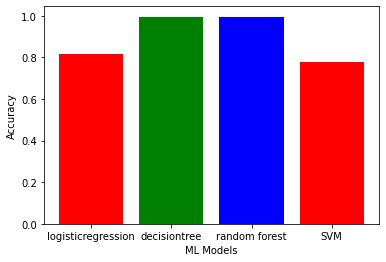

In [57]:
models=["logisticregression","decisiontree","random forest","SVM"]
accuracies=[lr_acc,dt_acc,rf_acc,svm_acc]
plt.bar(models,accuracies, color=['red','green','blue'])
plt.xlabel("ML Models")
plt.ylabel("Accuracy")
plt.show()

In [58]:
# Out of all the Algorithms, Random forest  works better with a nice accuracy followed by Decision tree
#and support vector

In [59]:
#LET'S PREDICT( random forest as it gives 99% accuracy)

In [60]:
X

array([[0.00000e+00, 5.20710e+02, 1.62800e+01, ..., 7.21300e+01,
        8.36000e+00, 2.02000e+03],
       [0.00000e+00, 1.68228e+03, 5.48400e+01, ..., 1.54530e+02,
        2.73600e+01, 2.02000e+03],
       [0.00000e+00, 1.81580e+03, 4.93500e+01, ..., 1.72630e+02,
        2.81200e+01, 2.02000e+03],
       ...,
       [2.50000e+01, 3.90530e+02, 4.28000e+00, ..., 4.80600e+01,
        1.20000e+00, 2.02300e+03],
       [2.50000e+01, 3.00410e+02, 1.36000e+00, ..., 4.88900e+01,
        0.00000e+00, 2.02300e+03],
       [2.50000e+01, 4.27250e+02, 6.00000e+00, ..., 6.14100e+01,
        2.00000e-01, 2.02300e+03]])

In [61]:
# prediction using decision tree
pred2=dt.predict([[25, 427.25, 6.00, 88.69, 10.73, 52.36, 61.41, 0.20, 2023]])
pred2

array([0])

In [62]:
# prediction using svm tree
pred3=svm.predict([[25, 427.25, 6.00, 88.69, 10.73, 52.36, 61.41, 0.20, 2023]])
pred3

array([0])

In [63]:
pred4=lr.predict([[0, 427.25, 6.00, 88.69, 10.73, 52.36, 61.41, 0.20, 2024]])
pred4

array([0])

In [64]:
#LET'S PREDICT for 2024

In [65]:
# prediction using random forest
pred1=rf.predict([[4, 42.25, 65.00, 882.69, 120.73, 512.36, 61.41, 0.20, 2024]])
pred1

array([4])